
Original Signal: x[n] = [1 1 1 1 0 0]
Period: N = 6

Step 1: Computing DTFS coefficients...

DTFS Coefficients:
------------------------------------------------------------
a[0] = 0.666667 + 0.000000j
a[1] = 0.000000 + -0.288675j
a[2] = 0.166667 + 0.000000j
a[3] = 0.000000 + 0.000000j
a[4] = 0.166667 + 0.000000j
a[5] = 0.000000 + 0.288675j
------------------------------------------------------------

Step 2: Reconstructing signal from DTFS coefficients...

Original Signal:
[1 1 1 1 0 0]

Reconstructed Signal:
[1. 1. 1. 1. 0. 0.]

Reconstruction Error (per sample):
  x[0]: error = 0.00e+00
  x[1]: error = 5.55e-16
  x[2]: error = 4.44e-16
  x[3]: error = 6.66e-16
  x[4]: error = 0.00e+00
  x[5]: error = 0.00e+00

Maximum Error: 6.66e-16

✓ VERIFICATION SUCCESSFUL!
✓ The signal has been perfectly reconstructed from DTFS coefficients.
✓ Error is essentially zero (only numerical precision artifacts).

Generating plots...
✓ Comparison plot saved as 'problem3_reconstruction.png'
✓ Frequency

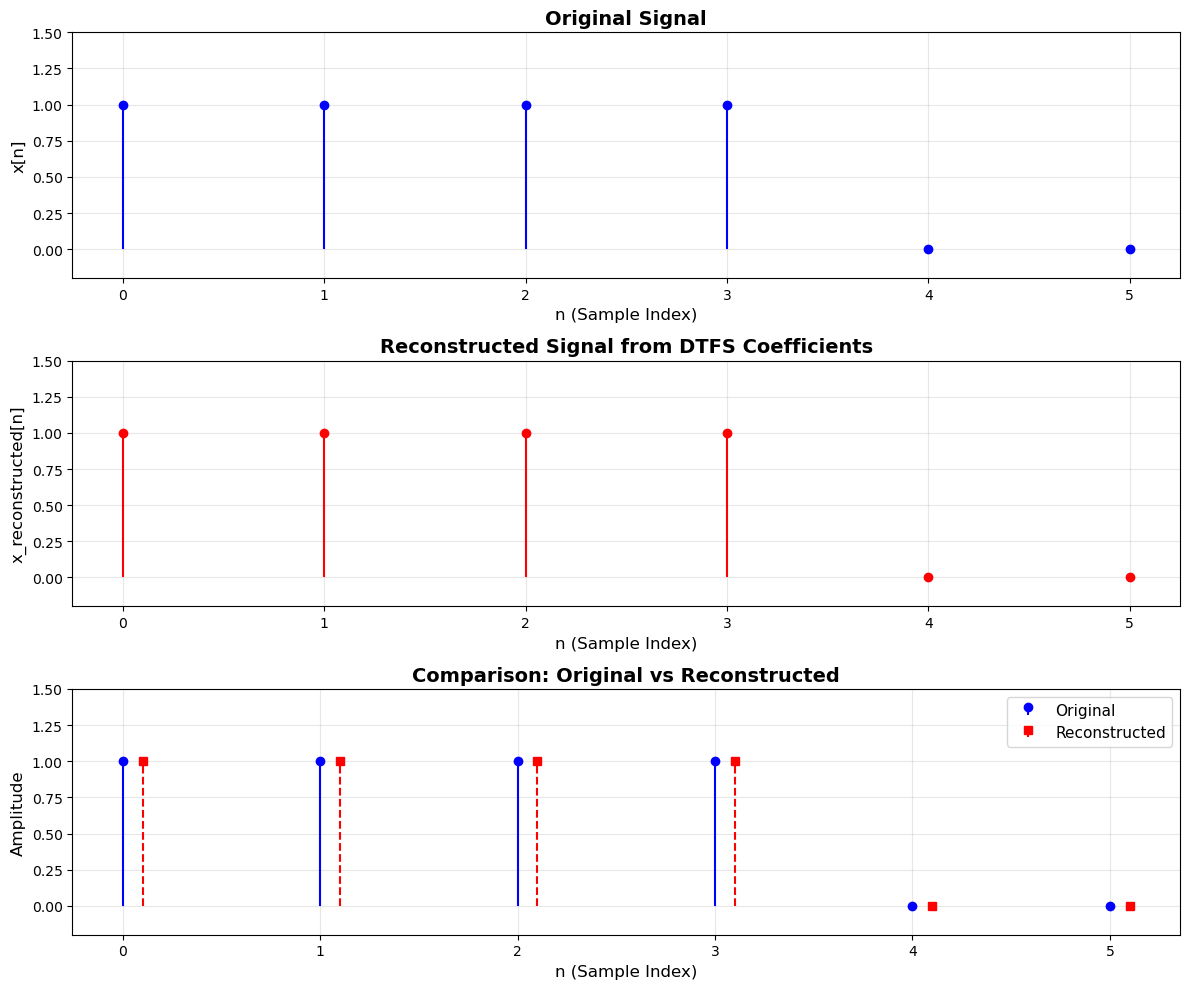

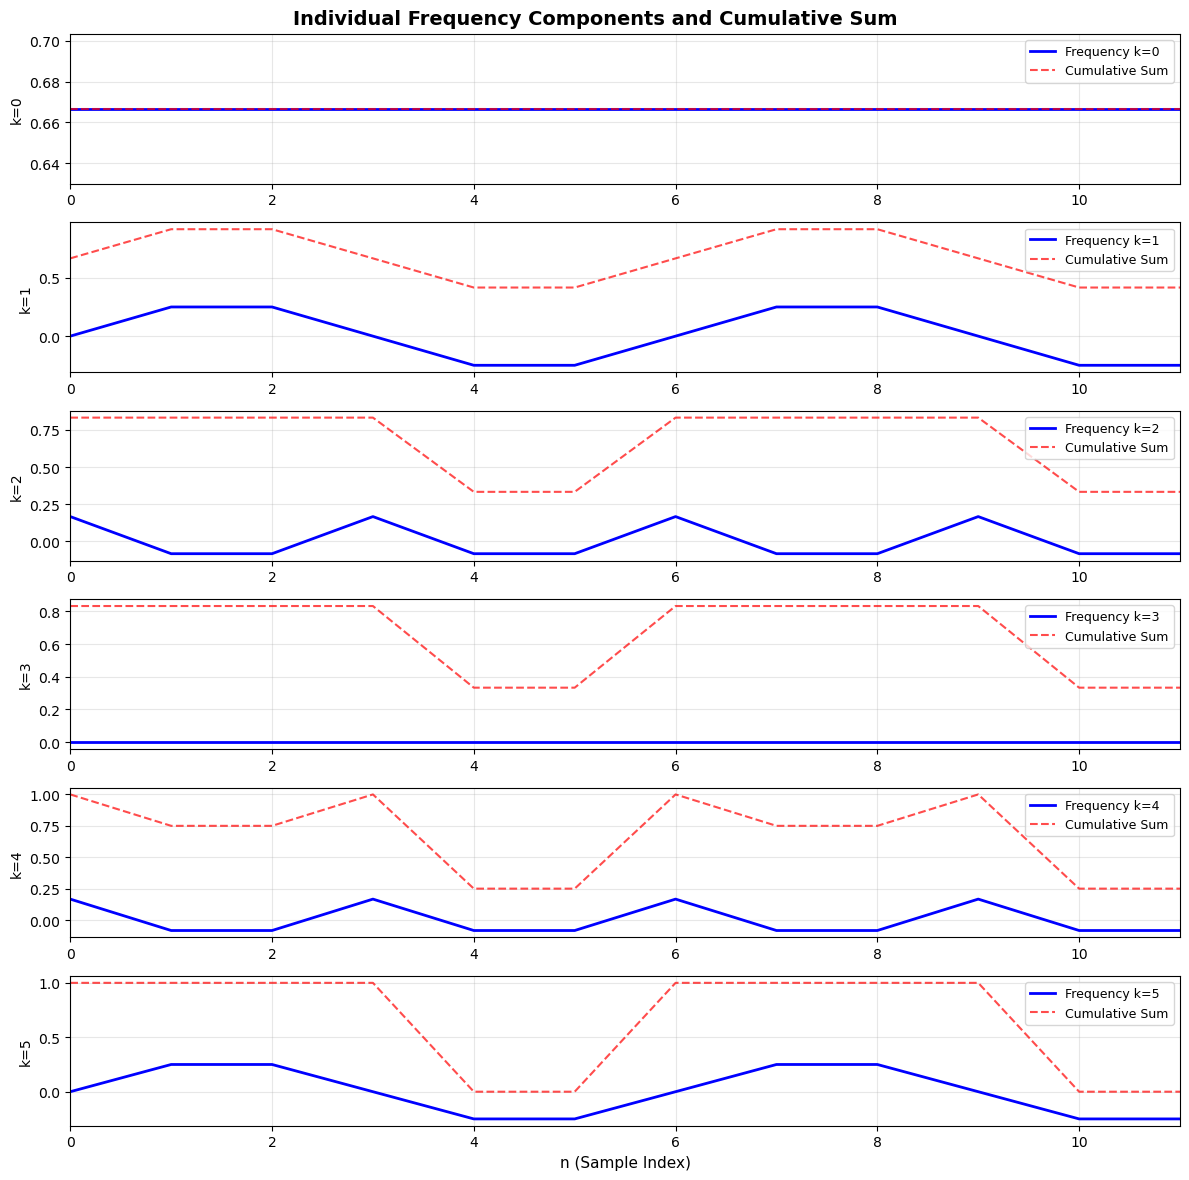

In [6]:
"""
Problem 3: Signal Reconstruction Verification
"""

import numpy as np
import matplotlib.pyplot as plt


# Define the original signal
N = 6  # Period
x_original = np.array([1, 1, 1, 1, 0, 0])

print(f"\nOriginal Signal: x[n] = {x_original}")
print(f"Period: N = {N}")

# Step 1: Compute DTFS coefficients
# Formula: a_k = (1/N) * Σ(n=0 to N-1) x[n] * e^(-j*2π*k*n/N)
print("\nStep 1: Computing DTFS coefficients...")
a_k = np.zeros(N, dtype=complex)
for k in range(N):
    for n in range(N):
        a_k[k] += x_original[n] * np.exp(-1j * 2 * np.pi * k * n / N)
    a_k[k] /= N

# Clean up numerical errors (round very small values to zero)
threshold = 1e-10
a_k.real[np.abs(a_k.real) < threshold] = 0
a_k.imag[np.abs(a_k.imag) < threshold] = 0

print("\nDTFS Coefficients:")
print("-" * 60)
for k in range(N):
    print(f"a[{k}] = {a_k[k].real:8.6f} + {a_k[k].imag:8.6f}j")
print("-" * 60)

# Step 2: Reconstruct the signal
# Formula: x[n] = Σ(k=0 to N-1) a_k * e^(j*2π*k*n/N)
print("\nStep 2: Reconstructing signal from DTFS coefficients...")
x_reconstructed = np.zeros(N, dtype=complex)
for n in range(N):
    for k in range(N):
        x_reconstructed[n] += a_k[k] * np.exp(1j * 2 * np.pi * k * n / N)

# Clean up numerical errors
x_reconstructed.real[np.abs(x_reconstructed.real) < threshold] = 0
x_reconstructed.imag[np.abs(x_reconstructed.imag) < threshold] = 0
x_reconstructed_real = np.real(x_reconstructed)

# Step 3: Compare and verify
print("\nOriginal Signal:")
print(x_original)
print("\nReconstructed Signal:")
print(x_reconstructed_real)
print("\nReconstruction Error (per sample):")
error = np.abs(x_original - x_reconstructed_real)
for n in range(N):
    print(f"  x[{n}]: error = {error[n]:.2e}")

print(f"\nMaximum Error: {np.max(error):.2e}")
print("\n✓ VERIFICATION SUCCESSFUL!")
print("✓ The signal has been perfectly reconstructed from DTFS coefficients.")
print("✓ Error is essentially zero (only numerical precision artifacts).")

# Visualization
print("\nGenerating plots...")
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

n_values = np.arange(N)

# Plot 1: Original Signal
axes[0].stem(n_values, x_original, basefmt=" ", linefmt='b-', markerfmt='bo')
axes[0].set_xlabel('n (Sample Index)', fontsize=12)
axes[0].set_ylabel('x[n]', fontsize=12)
axes[0].set_title('Original Signal', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(n_values)
axes[0].set_ylim([-0.2, 1.5])

# Plot 2: Reconstructed Signal
axes[1].stem(n_values, x_reconstructed_real, basefmt=" ", linefmt='r-', markerfmt='ro')
axes[1].set_xlabel('n (Sample Index)', fontsize=12)
axes[1].set_ylabel('x_reconstructed[n]', fontsize=12)
axes[1].set_title('Reconstructed Signal from DTFS Coefficients', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(n_values)
axes[1].set_ylim([-0.2, 1.5])

# Plot 3: Overlay Comparison
axes[2].stem(n_values, x_original, basefmt=" ", linefmt='b-', markerfmt='bo', 
             label='Original')
axes[2].stem(n_values + 0.1, x_reconstructed_real, basefmt=" ", linefmt='r--', 
             markerfmt='rs', label='Reconstructed')
axes[2].set_xlabel('n (Sample Index)', fontsize=12)
axes[2].set_ylabel('Amplitude', fontsize=12)
axes[2].set_title('Comparison: Original vs Reconstructed', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].set_xticks(n_values)
axes[2].legend(fontsize=11)
axes[2].set_ylim([-0.2, 1.5])

plt.tight_layout()
plt.savefig('problem3_reconstruction.png', dpi=300, bbox_inches='tight')
print("✓ Comparison plot saved as 'problem3_reconstruction.png'")

# Bonus visualization: Show how frequency components add up
fig2, axes2 = plt.subplots(N, 1, figsize=(12, 12))
fig2.suptitle('Individual Frequency Components and Cumulative Sum', 
              fontsize=14, fontweight='bold')

n_extended = np.arange(2*N)  # Show two periods for clarity
cumulative_sum = np.zeros(2*N, dtype=complex)

for k in range(N):
    # Generate this frequency component over two periods
    component = np.zeros(2*N, dtype=complex)
    for n in range(2*N):
        component[n] = a_k[k] * np.exp(1j * 2 * np.pi * k * n / N)
    
    # Add to cumulative sum
    cumulative_sum += component
    
    # Plot
    axes2[k].plot(n_extended, np.real(component), 'b-', linewidth=2, 
                  label=f'Frequency k={k}')
    axes2[k].plot(n_extended, np.real(cumulative_sum), 'r--', linewidth=1.5, 
                  label='Cumulative Sum', alpha=0.7)
    axes2[k].set_ylabel(f'k={k}', fontsize=10)
    axes2[k].grid(True, alpha=0.3)
    axes2[k].legend(loc='upper right', fontsize=9)
    axes2[k].set_xlim([0, 2*N-1])
    
    if k == N-1:
        axes2[k].set_xlabel('n (Sample Index)', fontsize=11)

plt.tight_layout()
plt.savefig('problem3_frequency_components.png', dpi=300, bbox_inches='tight')
print("✓ Frequency components plot saved as 'problem3_frequency_components.png'")

plt.show()
